In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from analysis_by_plot import draw_floorplan
from utils import spl

In [32]:
record_dir = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/yihe/records/'
experiment_id = 'test'     # 'moving-obstacle'#    'test-4models' #'steer_bias' #     
trial_id = 'sim_20240909_174933_Pomaria_1_int' # 'sim_20240813_151947_Pomaria_1_int'    # 'sim_20240815_165142_random'# 

data_dir = os.path.join(record_dir, experiment_id, trial_id)

model_names = 'MB4ONdiagonal', 'MB4ONaxial', 'MB2ONbilateral', #'MB2ONopponent'
ls_color = 'tab:red', 'tab:blue', 'tab:orange', 'tab:green'
n_model = len(model_names)

In [34]:
n_trial = 50
ls_var = 'x', 'y', 'f'

In [35]:
alldata = {}
for model_name in model_names:
    alldata[model_name] = {'steer': []}
    for var in ls_var:
        alldata[model_name][var] = []
        
    for trial in range(n_trial):
        data_name = 'Freight_{}_trial_{}_record.npz'.format(model_name, trial)
        data = np.load(os.path.join(data_dir, data_name), allow_pickle=True)
        alldata[model_name]['steer'].append(data['extra'][()]['steer_mode'])
        for var in ls_var:
            alldata[model_name][var].append(data[var])
            
scene_name = data['scene_name']
pos_start_goal = np.transpose([data['pos_start'][:2], data['pos_goal'][:2]])

Text(0.5, 1.0, 'Pomaria_1_int')

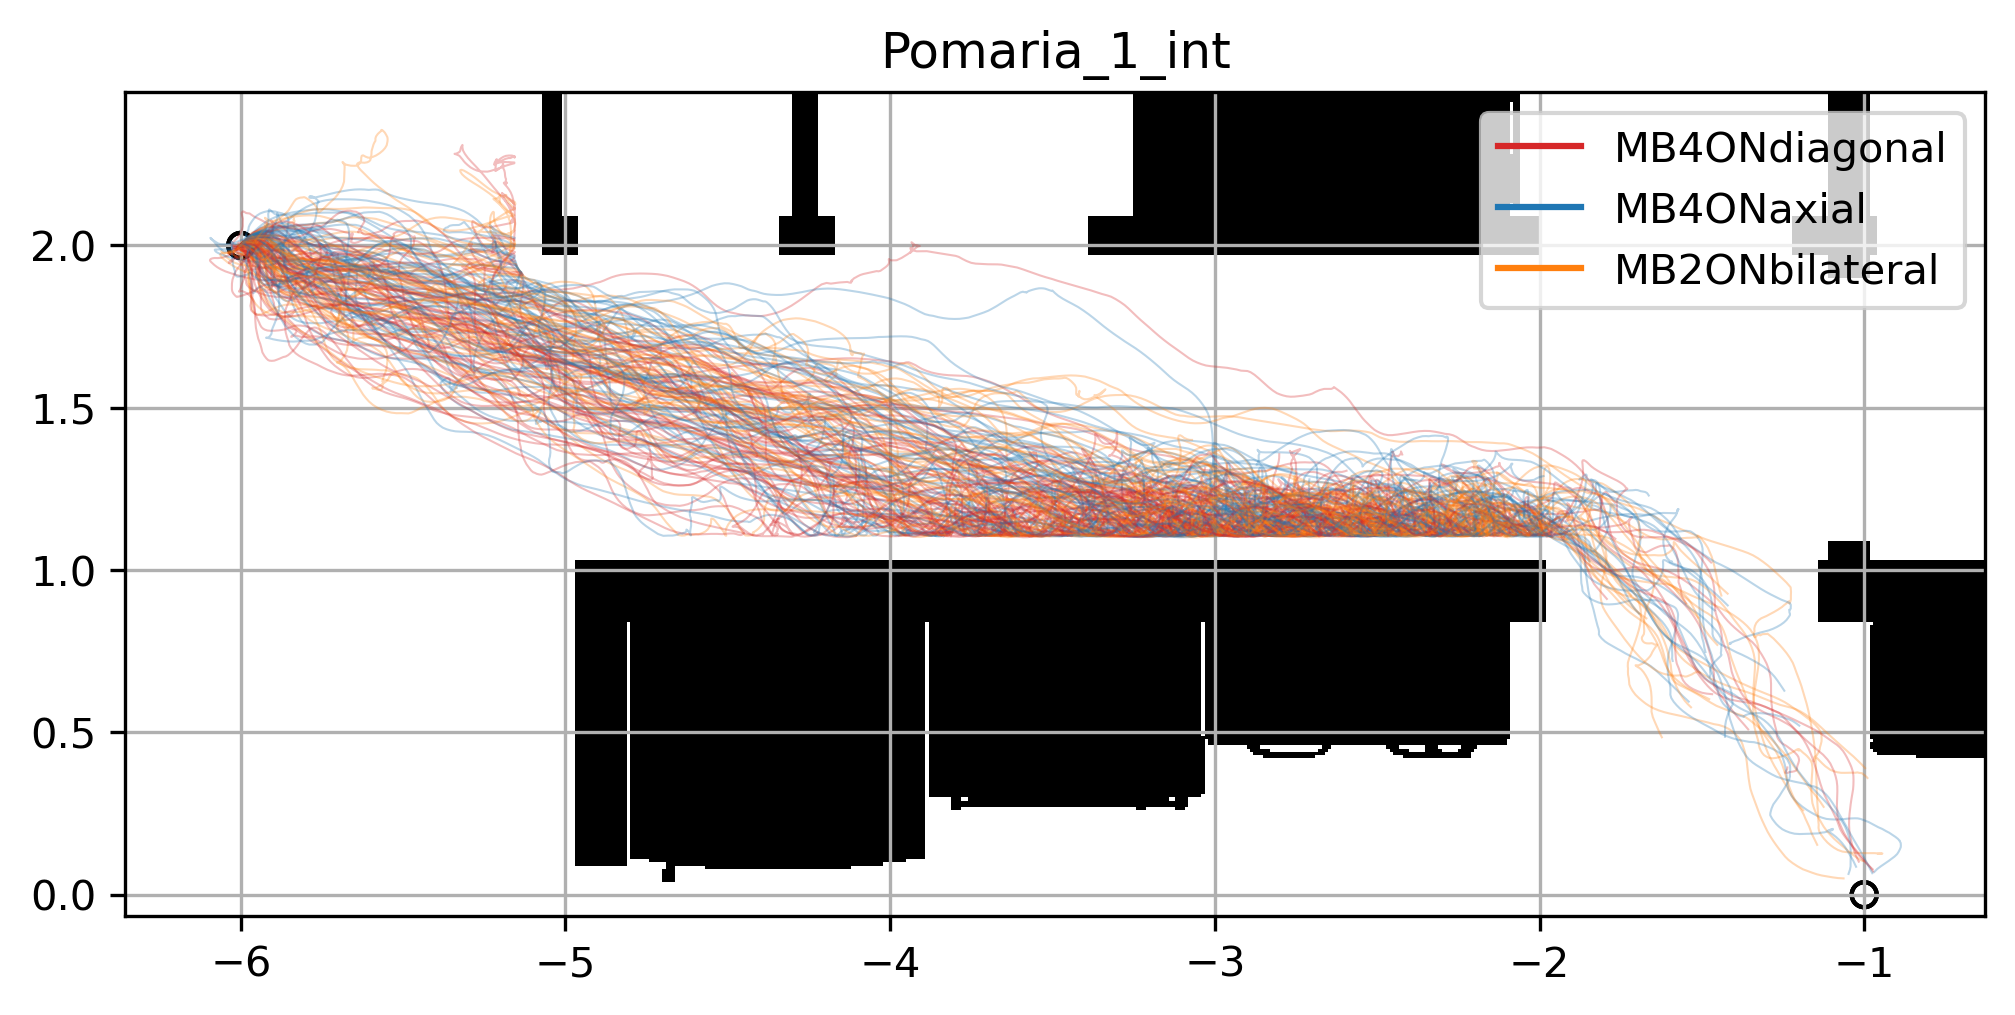

In [36]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

for trial in range(n_trial):
    for model_name, color in zip(model_names, ls_color):
        x, y = alldata[model_name]['x'][trial], alldata[model_name]['y'][trial]
        if trial >= -45:
            ax.plot(x, y, 
                    c=color, alpha=0.3, #(trial + 1 + n_trial) / (n_trial * 2),
                    lw=.5)
                        
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
       
    
    
for model_name, color in zip(model_names, ls_color):
    ax.plot([], [], c=color, label=model_name)
    ax.scatter(*pos_start_goal, edgecolor='k', facecolor='none', marker='o')

ax.set_aspect('equal')
ax.legend()

floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
draw_floorplan(ax, floorplan, 0.01)
ax.set_xlim(xlim)
ax.set_ylim(ylim)    
ax.grid()
ax.set_title(scene_name)

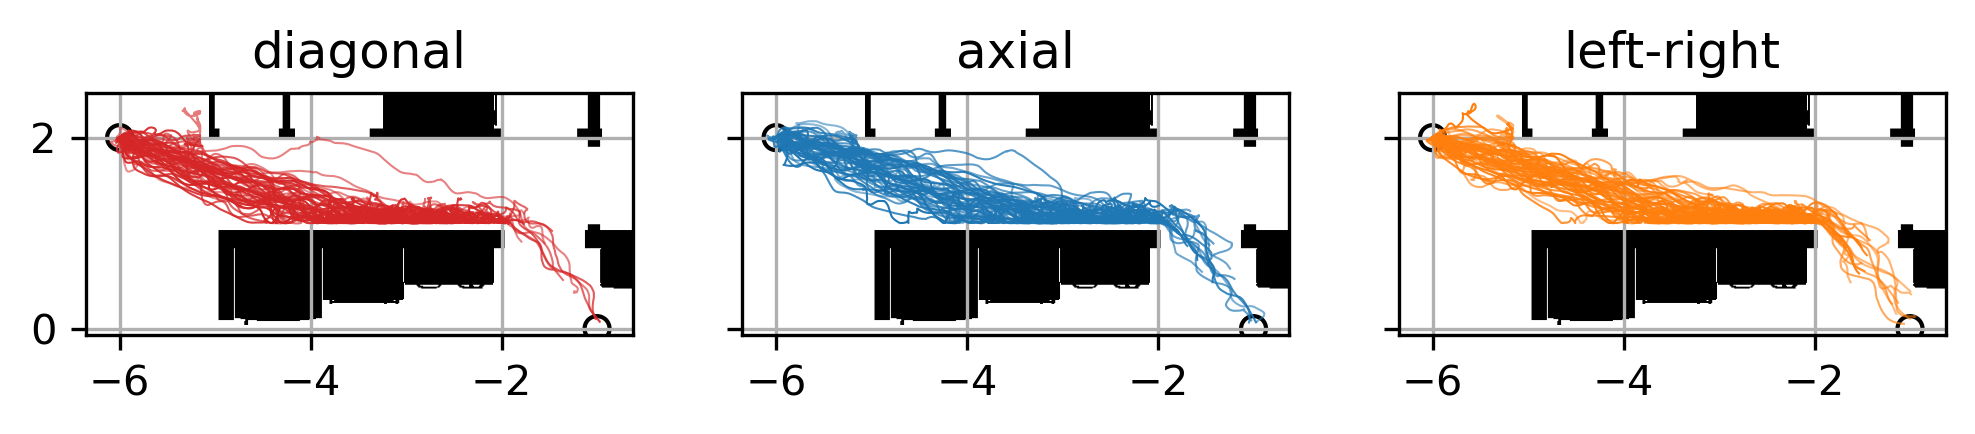

In [37]:
fig, axes = plt.subplots(1, n_model, figsize=(8, 7), dpi=300, sharex=True, sharey=True)


for model_name, color, ax in zip(model_names, ls_color, axes.flatten()):
    ax.plot([], [], c=color, label=model_name)
    ax.scatter(*pos_start_goal, edgecolor='k', facecolor='none', marker='o')
    for trial in range(n_trial):
#     for trial, aa in enumerate([0.5, 1]):
        x, y, force = [alldata[model_name][var][trial] for var in ls_var]
        if trial >= -4:
            ax.plot(x, y, 
                    c=color, alpha=(trial + 1 + n_trial) / (n_trial * 2),    # 0.7,#aa,# 
                    lw=.5)
                        
       

    ax.set_aspect('equal')

    floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
    draw_floorplan(ax, floorplan, 0.01)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)    
    ax.grid()
    
for ax, tit in zip(axes, ('diagonal', 'axial', 'left-right', 'forward-backward')):
    ax.set_title(tit)

(-0.04459364046651234, 1.0)

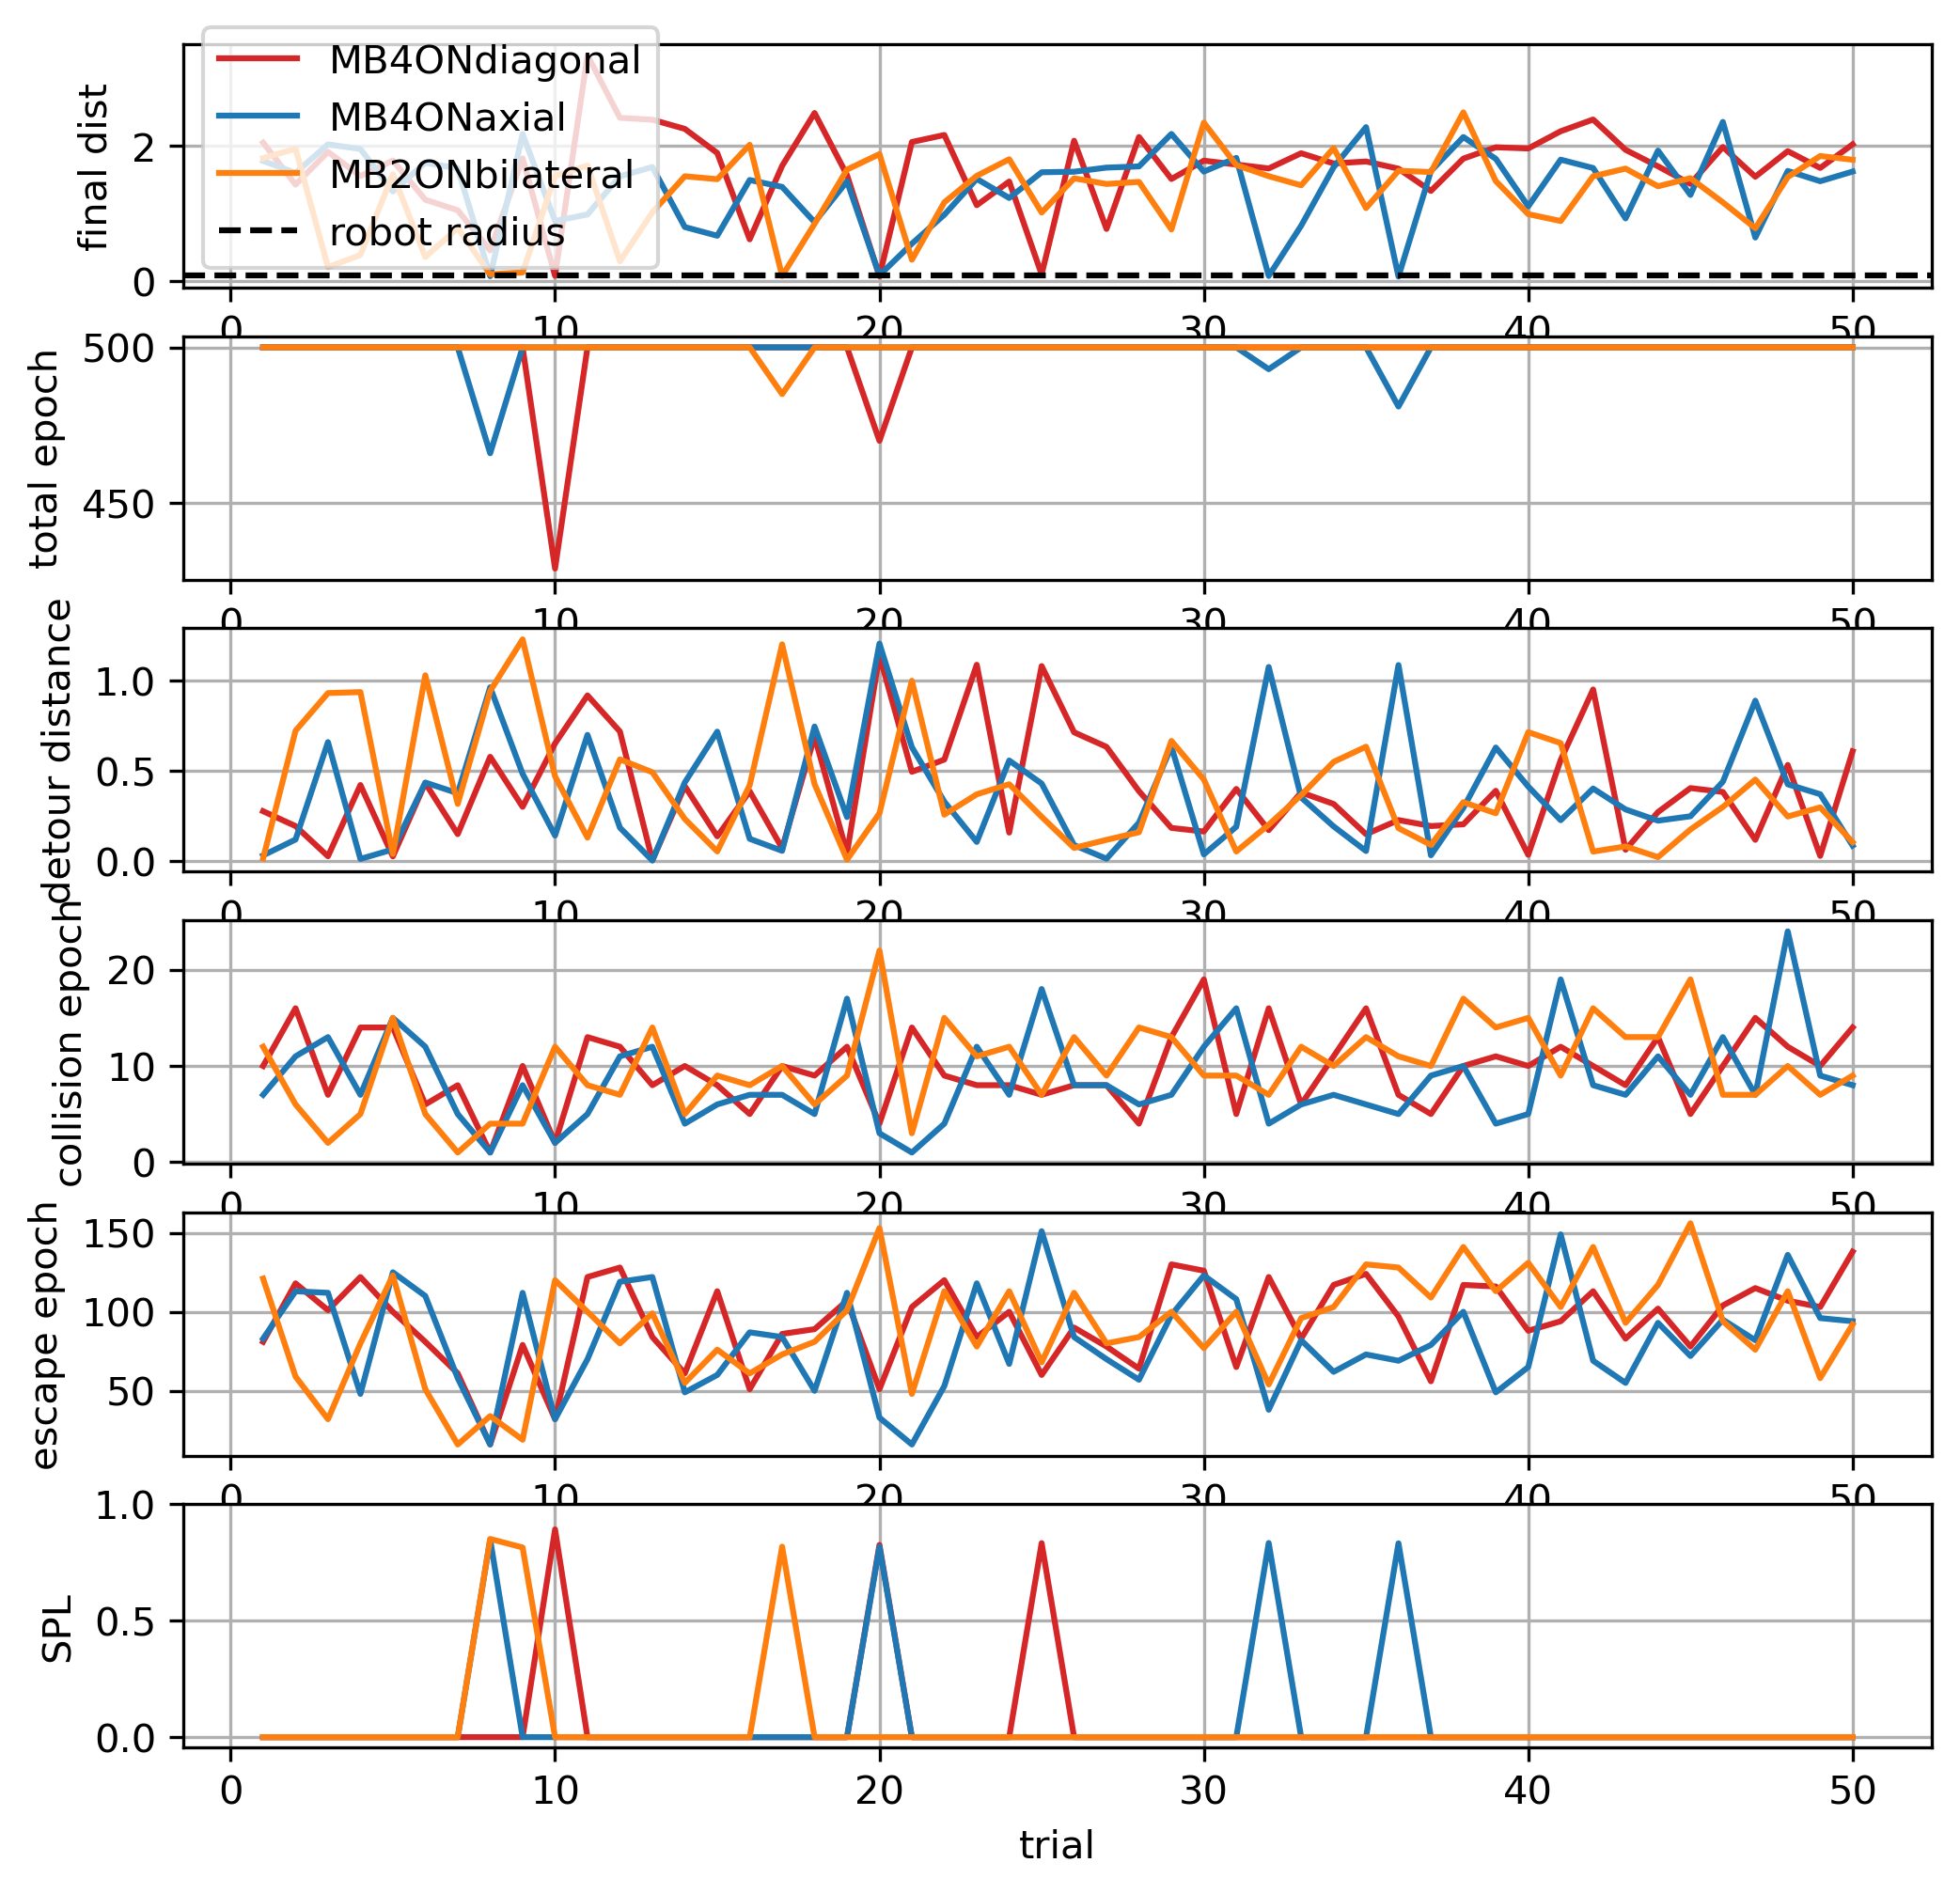

In [38]:
fig, axes = plt.subplots(6, 1, figsize=(8, 8), dpi=300)

trial_idx = np.arange(n_trial) + 1

shortest_dist = np.linalg.norm(pos_start_goal[:, -1] - pos_start_goal[:, 0]) 

for model_name, color in zip(model_names, ls_color):
    time_end = []    
    time_collision = []
    time_reflex = []
    end_dist = []
    straight = []
    val_spl = []
    for force, steer in zip(alldata[model_name]['f'], alldata[model_name]['steer']):
        time_collision.append(np.count_nonzero(force > 100))
        time_reflex.append(np.count_nonzero(steer == 'reflex'))
        
    for x, y in zip(alldata[model_name]['x'], alldata[model_name]['y']):
        path = np.transpose([x, y])
        end_dist.append(np.linalg.norm(data['pos_goal'][:2] - path[-1]))
        straight.append(np.linalg.norm(np.sum(np.linalg.norm(path[:-1] - path[1:], axis=1)) - shortest_dist))
        time_end.append(len(x))
        val_spl.append(spl(path, pos_start_goal[:, 1], shortest_dist))

        
    axes[0].plot(trial_idx, end_dist, c=color, label=model_name)
    axes[1].plot(trial_idx, time_end, c=color, label=model_name)
    axes[2].plot(trial_idx, straight, c=color, label=model_name)
    
    axes[3].plot(trial_idx, time_collision, c=color, label=model_name)
    axes[4].plot(trial_idx, time_reflex, c=color, label=model_name)
    axes[5].plot(trial_idx, val_spl, c=color, label=model_name)

    
axes[0].axhline(0.559 * 0.3 / 2, color='k', ls='dashed', label='robot radius')

    
for ax, tit in zip(axes, ('final dist', 'total epoch', 'detour distance', 'collision epoch', 'escape epoch', 'SPL')):
    ax.grid()
    ax.set_ylabel(tit)
    
axes[0].legend()
axes[-1].set_xlabel('trial')
axes[-1].set_ylim(top=1)

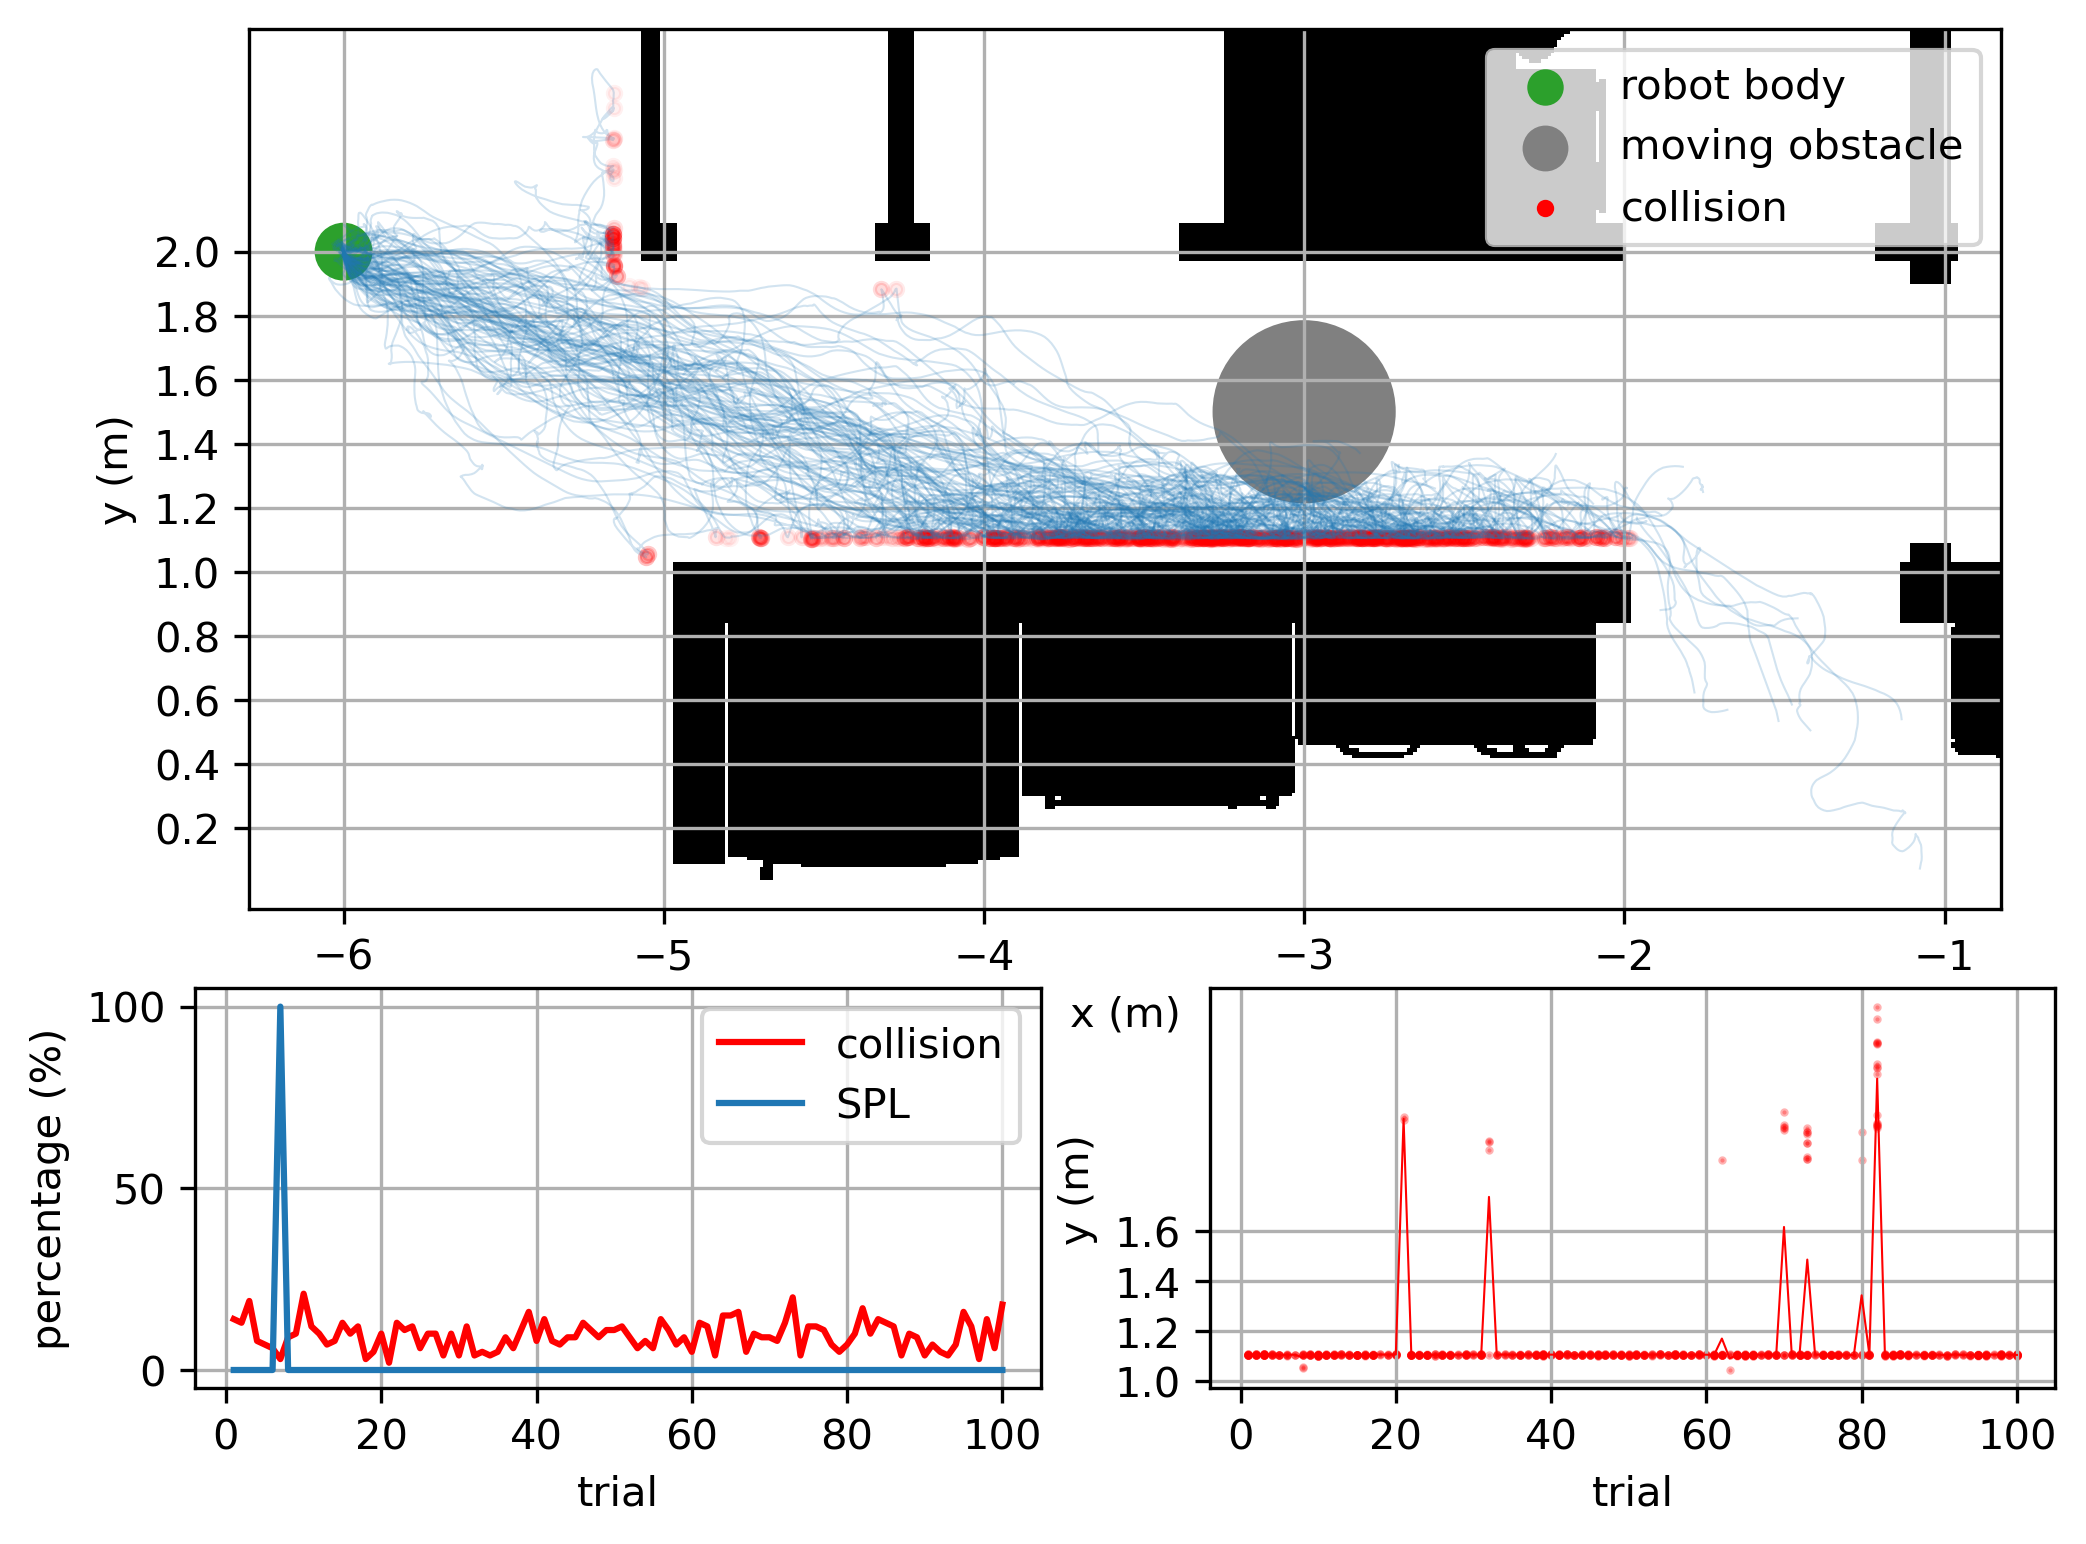

In [31]:
model_name, color = 'MB4ONdiagonal', 'tab:blue'

fig, axes = plt.subplot_mosaic('''
                                aa
                                aa
                                bd''', figsize=(8, 6), dpi=300)

ax = axes['a']
col_y, col_yy = [], []
for trial in range(n_trial):
    x, y = alldata[model_name]['x'][trial], alldata[model_name]['y'][trial]
    collision_idx = alldata[model_name]['f'][trial] > 100
    if trial >= 0:
        ax.plot(x, y, 
                c=color, alpha=0.2, #(trial + 1 + n_trial) / (n_trial * 2),
                lw=.5)
        
    ax.scatter(x[collision_idx], y[collision_idx], color='r', s=10, alpha=1/np.count_nonzero(collision_idx))
    col_y = np.concatenate((col_y, y[collision_idx]))
    col_yy.append(y[collision_idx])
                        
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
       
    
    
# for model_name, color in zip(('diagonal', 'axial', 'left-right', 'forward-backward'), ls_color):
#     ax.plot([], [], c=color, label=model_name)
#     ax.scatter(*pos_start_goal, edgecolor='k', facecolor='none', marker='o')

ax.set_aspect('equal')

floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
draw_floorplan(ax, floorplan, 0.01)
ax.set_xlim(xlim)
ax.set_ylim(ylim)    
ax.grid()


body = plt.Circle((-6, 2), 0.559 / 2 * 0.3, color='tab:green')
dynaobs = plt.Circle((-3, 1.5), 0.559 / 2, color='grey')
ax.add_patch(dynaobs)
ax.add_patch(body)

ax.scatter([], [], s=60, color='tab:green', label='robot body')
ax.scatter([], [], s=100, color='grey', label='moving obstacle')
ax.scatter([], [], s=10, color='r', label='collision')
ax.legend()
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_yticks(np.arange(0.2, 2.1, 0.2))

#####


trial_idx = np.arange(n_trial) + 1
shortest_dist = 6.449360748630709



time_end = []    
time_collision = []
time_reflex = []
end_dist = []
val_spl = []
for force, steer in zip(alldata[model_name]['f'], alldata[model_name]['steer']):
    time_collision.append(np.count_nonzero(force > 100))

for x, y in zip(alldata[model_name]['x'], alldata[model_name]['y']):
    path = np.transpose([x, y])
    end_dist.append(np.linalg.norm(data['pos_goal'][:2] - path[-1]))
    time_end.append(len(x))
    val_spl.append(spl(path, pos_start_goal[:, 1], shortest_dist, 0.3) * 100)



axes['b'].plot(trial_idx, time_collision, color='r', label='collision')
axes['b'].plot(trial_idx, val_spl, color='tab:blue', label='SPL')
axes['b'].legend()


ymean = []
for tid, cy in enumerate(col_yy):
    axes['d'].scatter(np.full_like(cy, tid + 1), cy, color='r', alpha=0.3, s=1)
    ym = np.mean(cy) if len(cy) > 0 else np.nan
    ymean.append(ym)
axes['d'].plot(trial_idx, ymean, color='r', lw=.5)
axes['d'].set_yticks(np.arange(1, 1.7, 0.2))

for ak, yl in zip('bd', ['percentage (%)', 'y (m)']):
    ax = axes[ak]
    ax.grid()
    ax.set_xlabel('trial')
    ax.set_ylabel(yl)

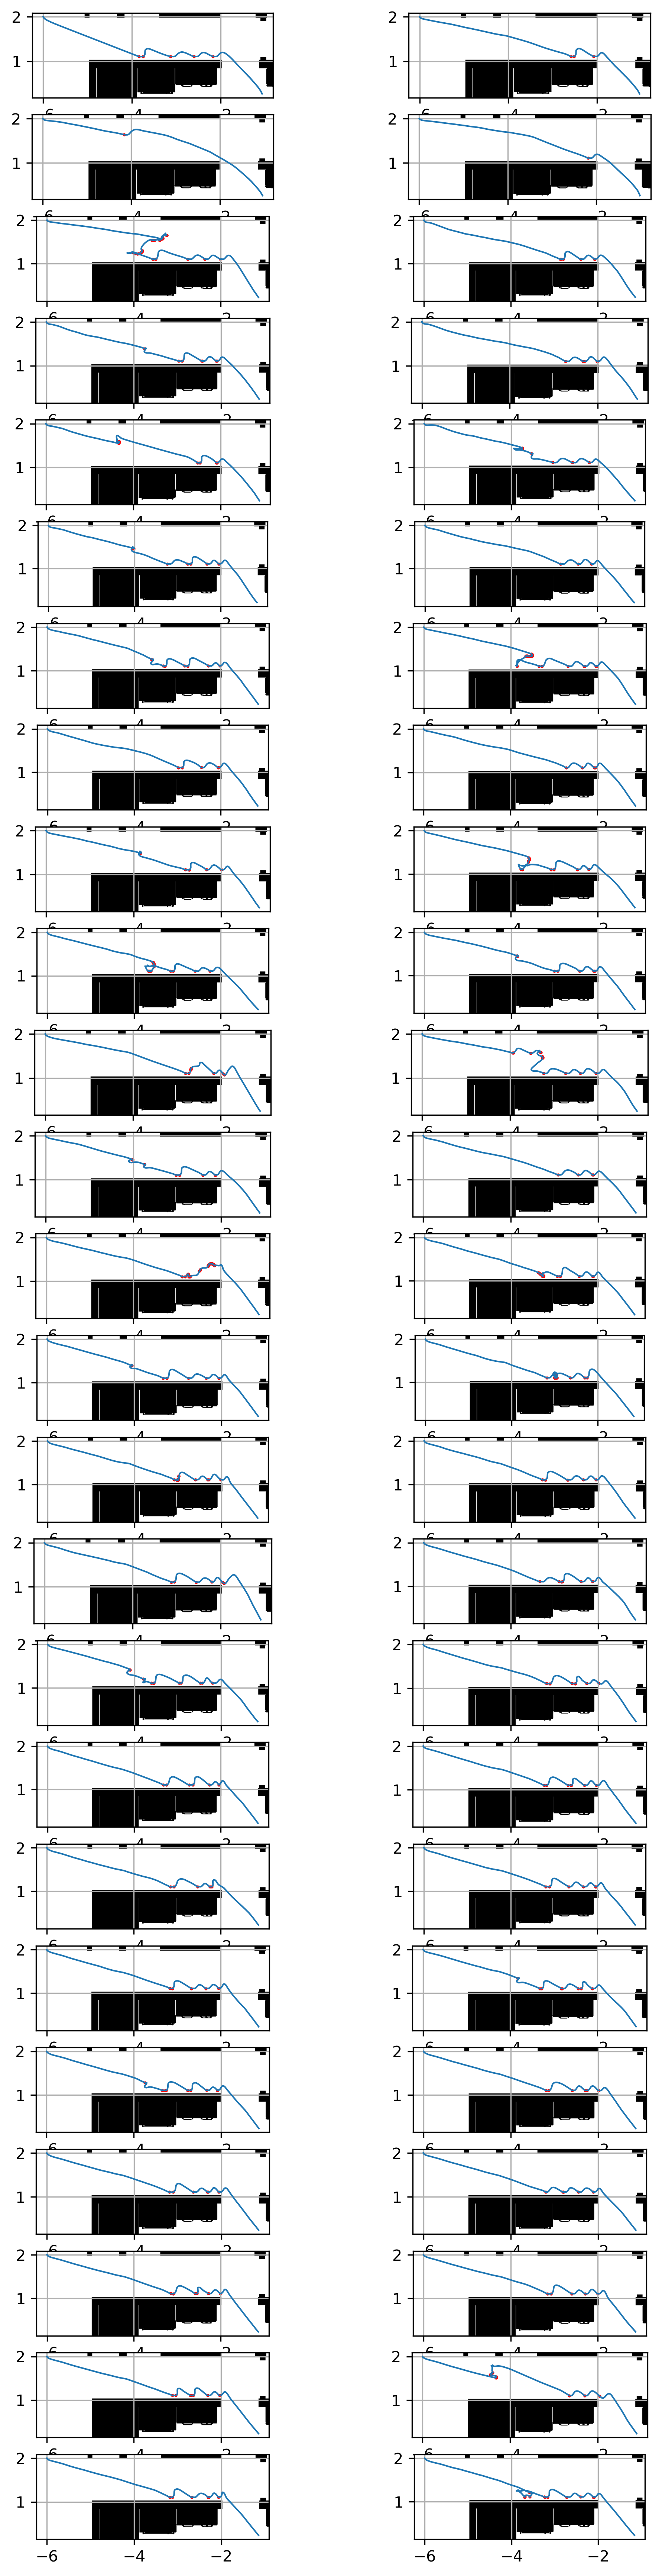

In [26]:
fig, axes = plt.subplots(25, 2, figsize=(8, 30), dpi=300)

for trial, ax in enumerate(axes.flatten()):
    x, y = alldata[model_name]['x'][trial], alldata[model_name]['y'][trial]
    collision_idx = alldata[model_name]['f'][trial] > 100
    if trial >= 0:
        ax.plot(x, y, 
                c=color, alpha=1, #(trial + 1 + n_trial) / (n_trial * 2),
                lw=1)
        
    ax.scatter(x[collision_idx], y[collision_idx], color='r', s=1)
                        
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
       
    
    
# for model_name, color in zip(('diagonal', 'axial', 'left-right', 'forward-backward'), ls_color):
#     ax.plot([], [], c=color, label=model_name)
#     ax.scatter(*pos_start_goal, edgecolor='k', facecolor='none', marker='o')

    ax.set_aspect('equal')

    floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
    draw_floorplan(ax, floorplan, 0.01)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)    
    ax.grid()